In [1]:
!pip install scikit-image

In [2]:
import kagglehub
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.filters import threshold_niblack, threshold_sauvola
from skimage.color import rgb2gray
from skimage import img_as_ubyte

In [3]:
path = kagglehub.dataset_download("andrewmvd/drive-digital-retinal-images-for-vessel-extraction")

print("Dataset path:", path)

100%|██████████| 28.0M/28.0M [00:00<00:00, 157MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction/versions/1


In [4]:
image_dir = os.path.join(path, "DRIVE", "training", "images")
mask_dir = os.path.join(path, "DRIVE", "training", "1st_manual")

image_name = sorted(os.listdir(image_dir))[0]
mask_name = sorted(os.listdir(mask_dir))[0]

image_path = os.path.join(image_dir, image_name)
mask_path = os.path.join(mask_dir, mask_name)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

print(image.shape, mask.shape)

(584, 565, 3) (584, 565)


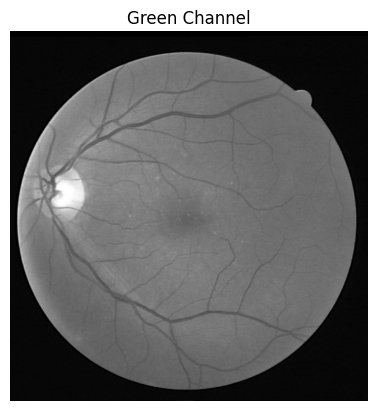

In [5]:
green_channel = image[:,:,1]

plt.imshow(green_channel, cmap='gray')
plt.title("Green Channel")
plt.axis('off')
plt.show()

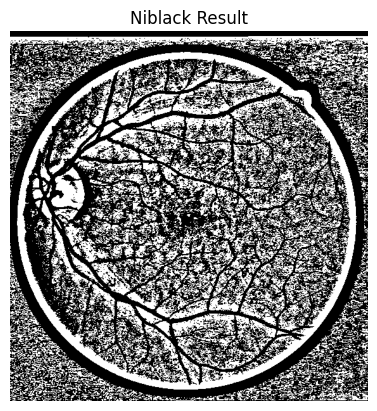

In [10]:
window_size = 25
k = -0.2

thresh_niblack = threshold_niblack(green_channel, window_size=window_size, k=k)

binary_niblack = green_channel > thresh_niblack
binary_niblack = binary_niblack.astype(np.uint8) * 255

plt.imshow(binary_niblack, cmap='gray')
plt.title("Niblack Result")
plt.axis('off')
plt.show()

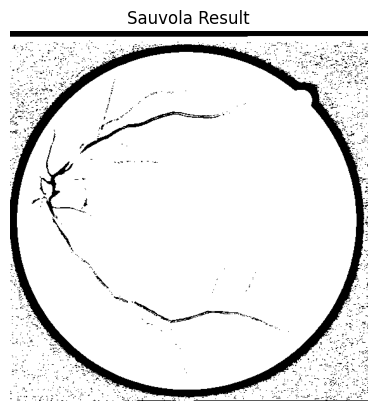

In [11]:
window_size = 25
k = 0.2

thresh_sauvola = threshold_sauvola(green_channel, window_size=window_size, k=k)

binary_sauvola = green_channel > thresh_sauvola
binary_sauvola = binary_sauvola.astype(np.uint8) * 255

plt.imshow(binary_sauvola, cmap='gray')
plt.title("Sauvola Result")
plt.axis('off')
plt.show()

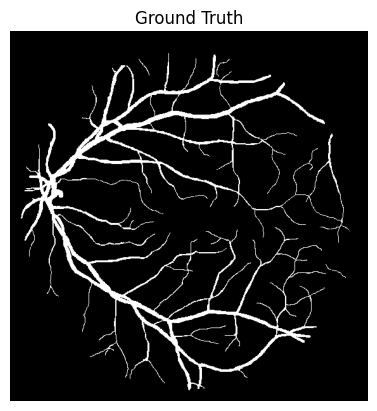

In [12]:
gt = mask > 0
gt = gt.astype(np.uint8) * 255

plt.imshow(gt, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')
plt.show()

In [13]:
def calculate_metrics(pred, gt):

    pred = pred > 0
    gt = gt > 0

    TP = np.logical_and(pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()

    sensitivity = TP / (TP + FN + 1e-6)

    dice = (2 * TP) / (2 * TP + FP + FN + 1e-6)

    jaccard = TP / (TP + FP + FN + 1e-6)

    return sensitivity, dice, jaccard

In [14]:
sens_n, dice_n, jac_n = calculate_metrics(binary_niblack, gt)

sens_s, dice_s, jac_s = calculate_metrics(binary_sauvola, gt)

print("Niblack Metrics:")
print("Sensitivity:", sens_n)
print("Dice:", dice_n)
print("Jaccard:", jac_n)

print("\nSauvola Metrics:")
print("Sensitivity:", sens_s)
print("Dice:", dice_s)
print("Jaccard:", jac_s)

Niblack Metrics:
Sensitivity: 0.08419174304143921
Dice: 0.02495447251206581
Jaccard: 0.012634884697470984

Sauvola Metrics:
Sensitivity: 0.8689674750235636
Dice: 0.13447176513369208
Jaccard: 0.07208240680598915


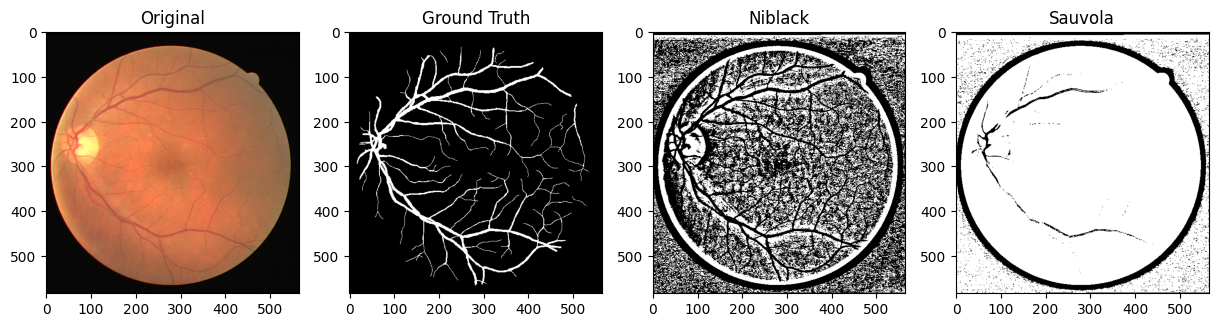

In [15]:
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Original")

plt.subplot(1,4,2)
plt.imshow(gt, cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,4,3)
plt.imshow(binary_niblack, cmap='gray')
plt.title("Niblack")

plt.subplot(1,4,4)
plt.imshow(binary_sauvola, cmap='gray')
plt.title("Sauvola")

plt.show()

In [17]:
results = []

for img_name, msk_name in zip(sorted(os.listdir(image_dir)), sorted(os.listdir(mask_dir))):

    img = cv2.imread(os.path.join(image_dir, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    green = img[:,:,1]

    gt_mask = cv2.imread(os.path.join(mask_dir, msk_name), 0)
    gt_mask = gt_mask > 0
    gt_mask = gt_mask.astype(np.uint8) * 255

    # Niblack
    thresh_n = threshold_niblack(green, window_size=25, k=-0.2)
    pred_n = (green > thresh_n).astype(np.uint8) * 255

    # Sauvola
    thresh_s = threshold_sauvola(green, window_size=25, k=0.2)
    pred_s = (green > thresh_s).astype(np.uint8) * 255

    sens_n, dice_n, jac_n = calculate_metrics(pred_n, gt_mask)
    sens_s, dice_s, jac_s = calculate_metrics(pred_s, gt_mask)

    results.append([sens_n, dice_n, jac_n, sens_s, dice_s, jac_s])

results = np.array(results)

print("\nAVERAGE RESULTS:\n")

print("Niblack:")
print("Sensitivity:", results[:,0].mean())
print("Dice:", results[:,1].mean())
print("Jaccard:", results[:,2].mean())

print("\nSauvola:")
print("Sensitivity:", results[:,3].mean())
print("Dice:", results[:,4].mean())
print("Jaccard:", results[:,5].mean())


AVERAGE RESULTS:

Niblack:
Sensitivity: 0.09994605711947115
Dice: 0.033475497617197085
Jaccard: 0.01704327146780406

Sauvola:
Sensitivity: 0.8243950319642688
Dice: 0.1463937095008424
Jaccard: 0.0791608666730241
